In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

import gseapy as gp
from gseapy import dotplot
from scipy.stats import spearmanr

## Load & Align Data

In [22]:
# Training metadata + ML feature matrix (for sample names)
train_meta = pd.read_csv("../../datasets/csv_files/ml_datasets/train_data.csv")

# Random Survival Forest risk scores — aligned to the merge(clinical, expr).dropna() subset
risk_df = pd.read_csv("../../datasets/csv_files/rsf_risk_scores_train.csv")

# Align by sample_name (risk_df covers only the 101 samples with complete
# clinical + expression data; train_data.csv has 104 rows before that merge)
if "sample_name" in risk_df.columns:
    sample_group = dict(zip(risk_df["sample_name"], risk_df["risk_group"]))
else:
    # Fallback for CSVs generated before sample_name was added:
    # replicate the merge used in mutivariate_cox.ipynb to get the same subset
    expr_raw_tmp = pd.read_csv("../../datasets/csv_files/expression_matrix_train.csv", index_col=0)
    expr_samples = set(expr_raw_tmp.columns) - {"gene_symbol"}
    train_clean = (
        train_meta[train_meta["sample_name"].isin(expr_samples)]
        .dropna()
        .reset_index(drop=True)
    )
    assert len(train_clean) == len(risk_df), (
        f"Row count mismatch after expr filter: train_clean={len(train_clean)}, risk_df={len(risk_df)}"
    )
    sample_group = dict(zip(train_clean["sample_name"], risk_df["risk_group"]))

print(f"Training samples aligned : {len(sample_group)}")
print("Risk group counts        :", risk_df["risk_group"].value_counts().to_dict())
print("Cutoff (median risk score):", risk_df["risk_score"].median().round(4))

Training samples aligned : 104
Risk group counts        : {'Low Risk': 52, 'High Risk': 52}
Cutoff (median risk score): 13.2717


## Prepare Expression Matrix

Use the full pre-normalised expression matrix (all genes) for maximal KEGG pathway coverage, rather than the 263-gene DEG feature subset.

In [23]:
# Full expression matrix: rows = genes, columns = gene_symbol + sample IDs
expr_raw = pd.read_csv("../../datasets/csv_files/expression_matrix_train.csv",
                        index_col=0)          # drop unnamed row index

# Keep only training samples that have a risk group
train_samples = [c for c in expr_raw.columns if c in sample_group]
expr_train    = expr_raw[train_samples]

# Class vector: must be in the same order as expr_train columns
cls = [sample_group[s] for s in train_samples]

n_high = cls.count("High Risk")
n_low  = cls.count("Low Risk")
print(f"Expression matrix       : {expr_train.shape[0]:,} genes x {expr_train.shape[1]} samples")
print(f"High Risk / Low Risk    : {n_high} / {n_low}")
print(f"Positive phenotype (pos): High Risk")

Expression matrix       : 21,655 genes x 104 samples
High Risk / Low Risk    : 52 / 52
Positive phenotype (pos): High Risk


## GSEA — Training Set

Runs GSEA (`gseapy.gsea`) with phenotype permutation, replicating the paper's GSEA v4 analysis:
- Gene set: **KEGG_2021_Human** (equivalent to c2.cp.kegg from MSigDB)
- Ranking metric: signal-to-noise ratio
- Permutations: 1 000 phenotype permutations
- Significance threshold: **FDR < 25 %** (Benjamini–Hochberg)

In [24]:
# Rank genes by correlation with RSF risk score
gene_scores = []
for gene in expr_train.index:
    r, _ = spearmanr(expr_train.loc[gene], risk_df["risk_score"])
    gene_scores.append((gene, r))

rnk = (
    pd.DataFrame(gene_scores, columns=["gene", "score"])
    .dropna()
    .sort_values("score", ascending=False)
)

# Run preranked GSEA
pre_res = gp.prerank(
    rnk              = rnk,
    gene_sets        = "KEGG_2021_Human",
    permutation_num  = 1000,
    min_size         = 15,
    max_size         = 500,
    outdir           = None,
    seed             = 42,
    verbose          = False,
)
print("GSEA complete.")
print(f"Gene sets tested: {len(gs_res.res2d)}")

2026-04-12 05:44:28,771 [WARNING] Duplicated values found in preranked stats: 7.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


GSEA complete.
Gene sets tested: 304


## Results (FDR < 25 %)

In [25]:
res = pre_res.res2d.copy()

# Normalise column names across gseapy versions
col_map = {
    "NOM p-val": "pval",  "FDR q-val": "fdr",  "NES": "nes",
    "ES": "es",           "Lead_genes": "lead_genes",
    "Tag %": "tag_pct",   "Gene %": "gene_pct",
}
res = res.rename(columns={k: v for k, v in col_map.items() if k in res.columns})

# Coerce numeric
for c in ["es", "nes", "pval", "fdr"]:
    if c in res.columns:
        res[c] = pd.to_numeric(res[c], errors="coerce")

# Filter FDR < 0.25
sig = res[res["fdr"] < 0.25].sort_values("nes", ascending=False).reset_index(drop=True)

print(f"Total pathways tested    : {len(res)}")
print(f"Significant (FDR < 25%) : {len(sig)}")
print(f"  Enriched in High Risk  : {(sig['nes'] > 0).sum()}")
print(f"  Enriched in Low Risk   : {(sig['nes'] < 0).sum()}")

display_cols = [c for c in ["Term", "nes", "es", "pval", "fdr", "tag_pct", "lead_genes"]
                if c in sig.columns]
display(sig[display_cols].round(4))

Total pathways tested    : 304
Significant (FDR < 25%) : 96
  Enriched in High Risk  : 68
  Enriched in Low Risk   : 28


,Term,nes,es,pval,fdr,tag_pct,lead_genes
0,Glycosphingolipid biosynthesis,2.0325,0.5161,0.0000,0.0064,20/43,ST8SIA1;B3GNT5;FUT3;GCNT2;ABO;B3GNT3;B4GALT2;B...
1,Neuroactive ligand-receptor interaction,1.9877,0.3590,0.0000,0.0075,166/326,NMU;GABBR2;SLURP1;S1PR2;UCN2;GAL;CRHR1;OXT;SCT...
2,IL-17 signaling pathway,1.9587,0.4234,0.0000,0.0075,42/92,S100A9;S100A8;CXCL3;CCL7;LCN2;CXCL1;IKBKE;IL17...
3,Cytokine-cytokine receptor interaction,1.9375,0.3625,0.0000,0.0072,151/276,RELT;IL34;LTBR;CXCL3;IFNAR2;CCL7;IL1R2;CXCL1;T...
4,Cell cycle,1.8953,0.3938,0.0000,0.0103,35/122,CDC25A;CCNE1;CDC20;E2F1;E2F3;SKP2;TTK;CCNA2;CC...
...,...,...,...,...,...,...,...
91,Herpes simplex virus 1 infection,-1.8970,-0.3231,0.0000,0.0135,157/440,IKBKB;ZNF44;ZNF587;HCFC2;TRAF5;ZNF302;ZNF680;Z...
92,Circadian rhythm,-2.0022,-0.5481,0.0000,0.0056,17/28,SKP1;BTRC;PER3;PER2;PRKAB1;CRY2;BHLHE40;FBXL3;...
93,Propanoate metabolism,-2.0124,-0.5308,0.0022,0.0054,20/33,ABAT;ALDH6A1;ACACB;SUCLG2;ACSS3;ACAT1;SUCLA2;E...
94,Glycosylphosphatidylinositol (GPI)-anchor bios...,-2.1856,-0.6157,0.0000,0.0009,15/25,PIGK;PIGT;PIGH;PIGB;PIGV;PIGX;PIGG;PIGN;PIGS;P...


## Enrichment Score Plots

Running enrichment curves for the top 5 significant pathways (by absolute NES).

Saved: gsea_top_enriched_curves.png


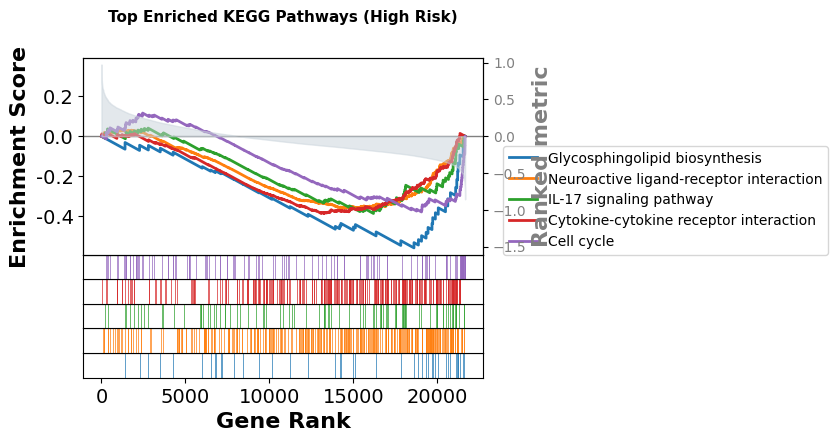

In [26]:
# Top 5 pathways by absolute NES
if len(sig) > 0:
    top_terms = sig.nlargest(min(5, len(sig)), "nes")["Term"].tolist()
    axs = gs_res.plot(
        terms          = top_terms,
        show_ranking   = True,
        legend_kws     = {"loc": (1.05, 0)},
        figsize        = (5, 4),
    )
    plt.suptitle("Top Enriched KEGG Pathways (High Risk)", fontsize=11,
                 fontweight="bold", y=1.02)
    plt.savefig("../../visuals/gsea_top_enriched_curves.png", dpi=150,
                bbox_inches="tight")
    print("Saved: gsea_top_enriched_curves.png")
    plt.show()
else:
    print("No significant pathways at FDR < 25%.")

Saved: gsea_top_protective_curves.png


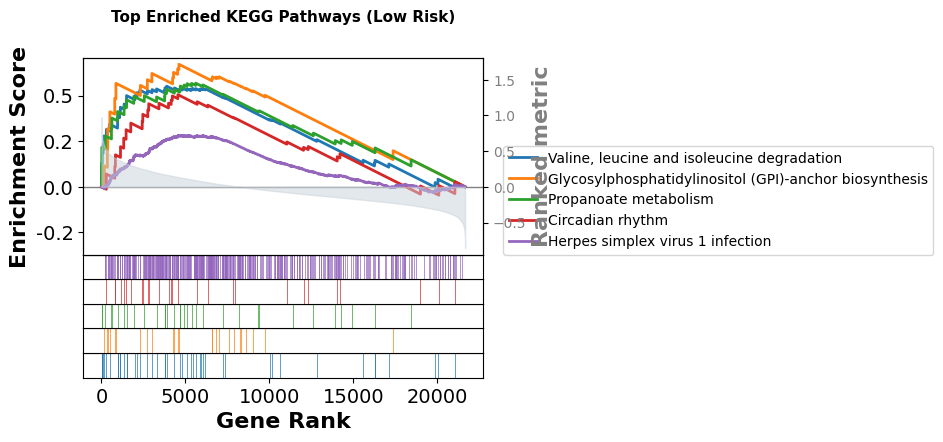

In [27]:
# Bottom 5 pathways (enriched in Low Risk)
if (sig["nes"] < 0).any():
    bot_terms = sig.nsmallest(min(5, (sig["nes"] < 0).sum()), "nes")["Term"].tolist()
    axs = gs_res.plot(
        terms        = bot_terms,
        show_ranking = True,
        legend_kws   = {"loc": (1.05, 0)},
        figsize      = (5, 4),
    )
    plt.suptitle("Top Enriched KEGG Pathways (Low Risk)", fontsize=11,
                 fontweight="bold", y=1.02)
    plt.savefig("../../visuals/gsea_top_protective_curves.png", dpi=150,
                bbox_inches="tight")
    print("Saved: gsea_top_protective_curves.png")
    plt.show()

## Dot Plot — Significant KEGG Pathways

Saved: gsea_dotplot.png


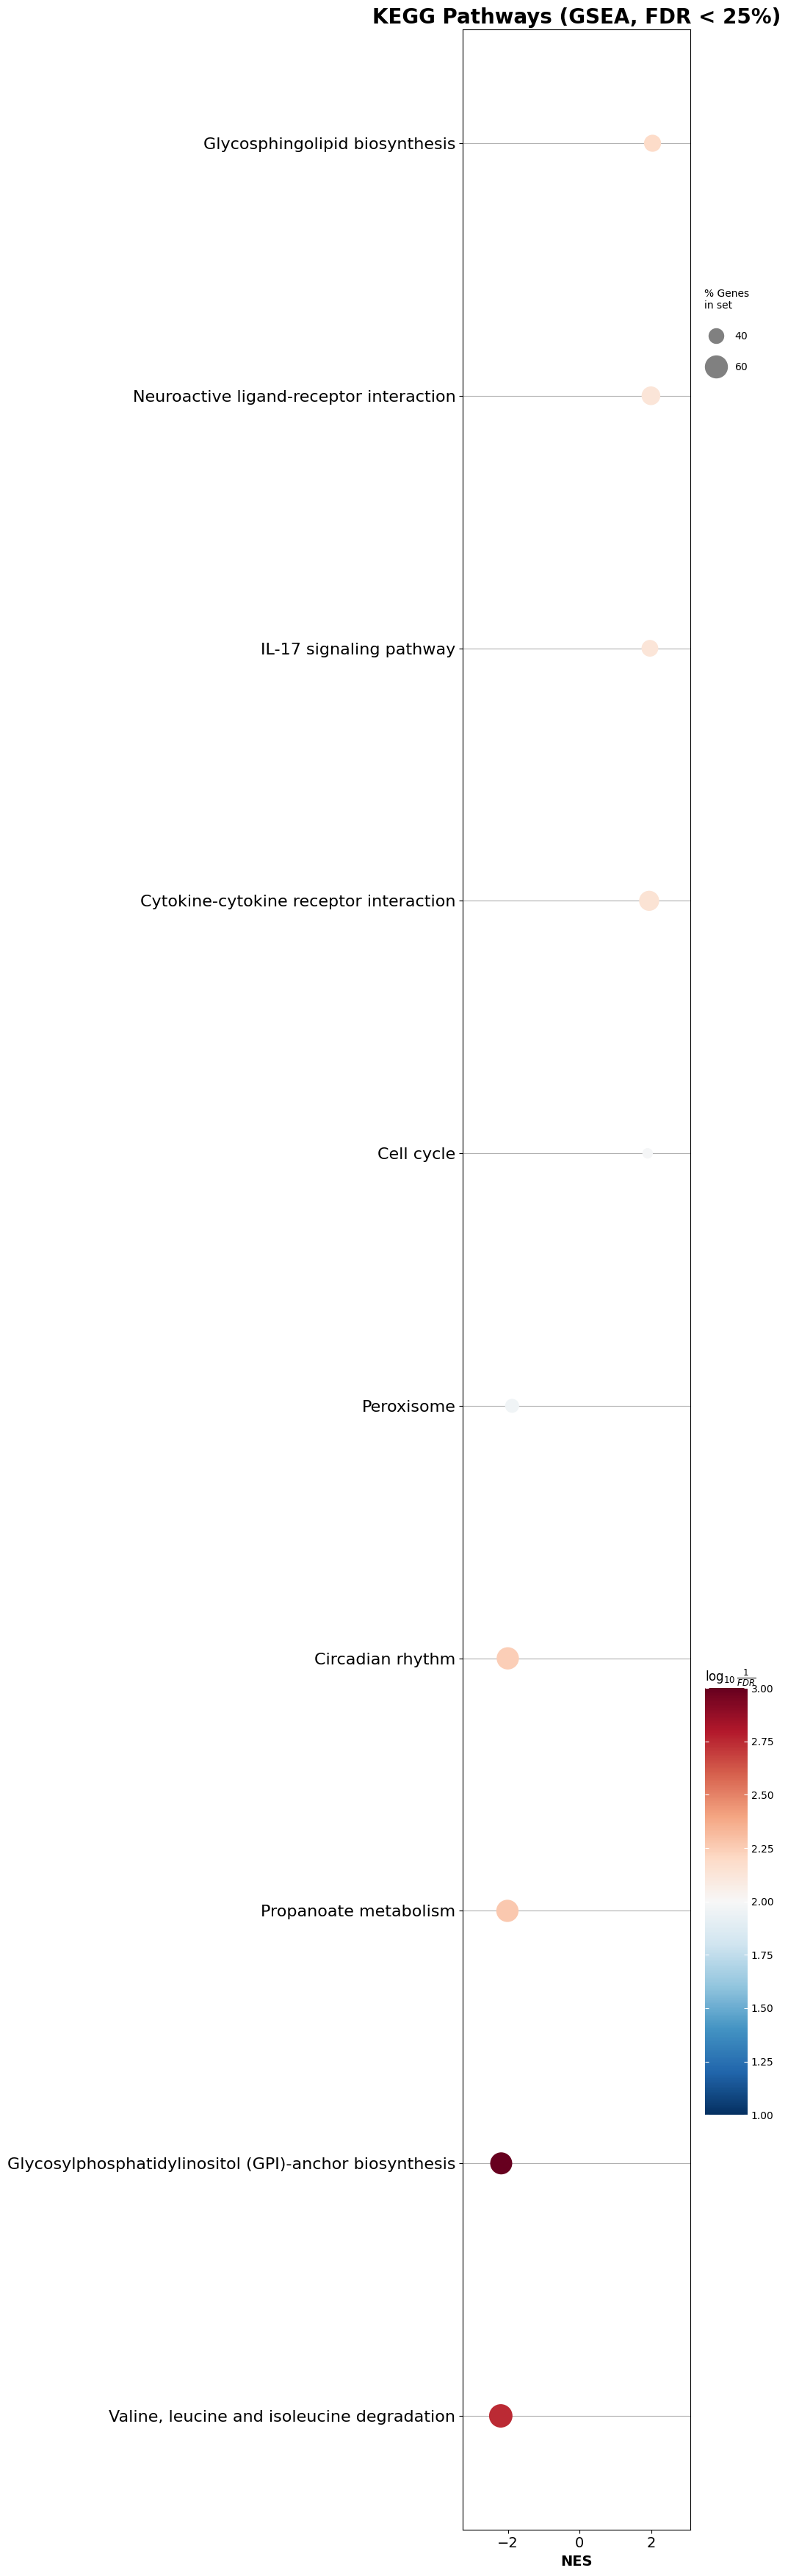

In [29]:
if len(sig) > 0:
    ax = dotplot(
        pre_res.res2d,
        column  = "FDR q-val" if "FDR q-val" in gs_res.res2d.columns else "fdr",
        title   = "KEGG Pathways (GSEA, FDR < 25%)",
        cmap    = plt.cm.RdBu_r,
        size    = 6,
        figsize = (5, max(4, len(sig) * 0.45 + 1)),
        cutoff  = 0.25,
        show_ring = False,
    )
    plt.savefig("../../visuals/gsea_dotplot.png", dpi=150, bbox_inches="tight")
    print("Saved: gsea_dotplot.png")
    plt.show()

## NES Bar Chart

Horizontal bar chart of normalised enrichment scores for significant pathways.
Red = enriched in High Risk; Blue = enriched in Low Risk.

Saved: gsea_nes_barplot.png


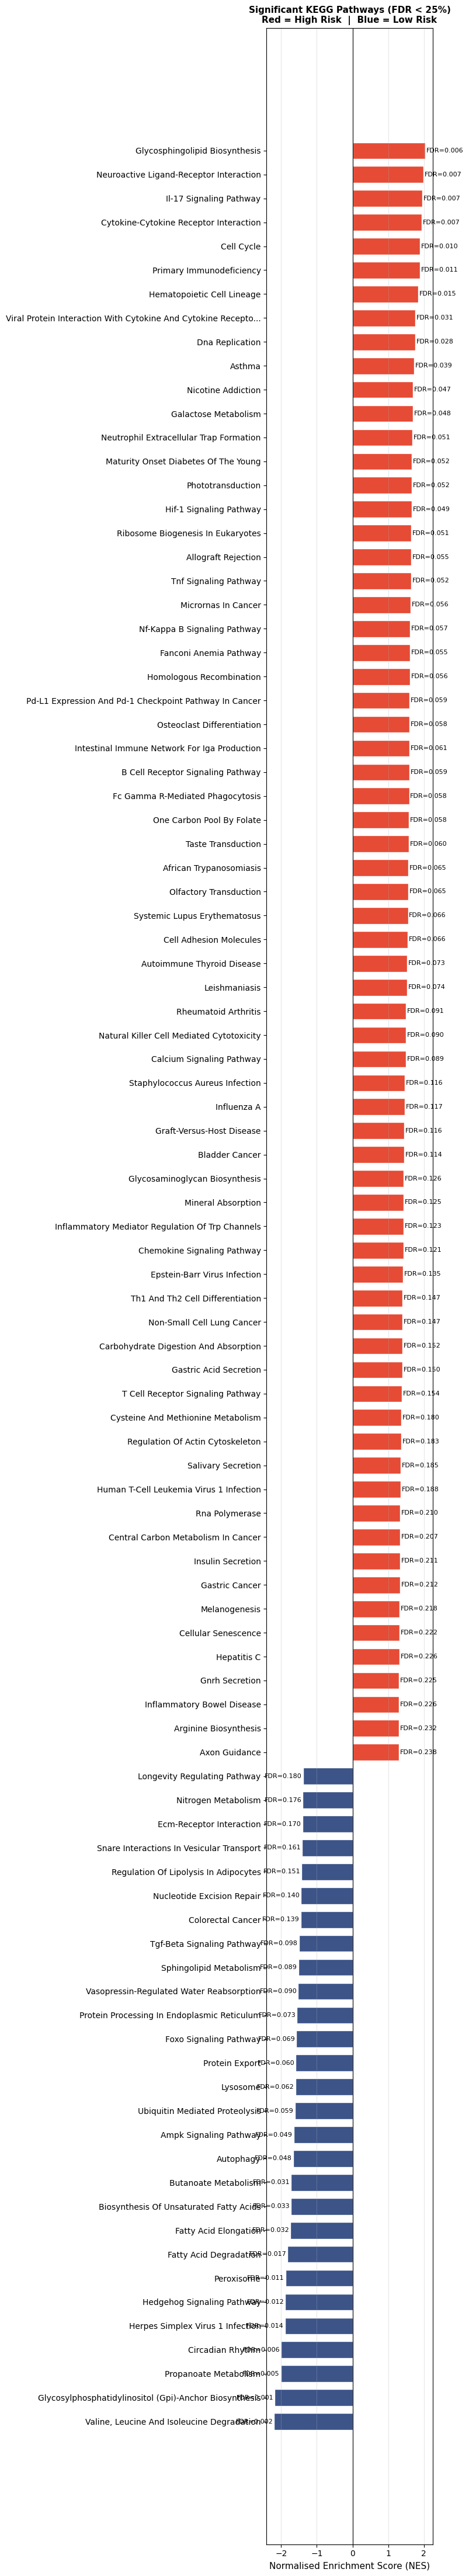

In [30]:
if len(sig) > 0:
    # Clean up pathway names (remove "Homo sapiens ..." suffixes)
    import re
    def clean_name(name):
        name = re.sub(r" Homo sapiens.*", "", name)
        name = name.replace("_", " ").title()
        return name[:60] + ("..." if len(name) > 60 else "")

    plot_df = sig[["Term", "nes", "fdr"]].copy()
    plot_df["label"] = plot_df["Term"].apply(clean_name)
    plot_df = plot_df.sort_values("nes")

    colors = ["#3C5488" if v < 0 else "#E64B35" for v in plot_df["nes"]]

    fig, ax = plt.subplots(figsize=(8, max(4, len(plot_df) * 0.45 + 1)))
    bars = ax.barh(plot_df["label"], plot_df["nes"],
                   color=colors, edgecolor="white", height=0.7)

    # FDR labels
    for bar, fdr_val in zip(bars, plot_df["fdr"]):
        x = bar.get_width()
        offset = 0.03 if x >= 0 else -0.03
        ha = "left" if x >= 0 else "right"
        ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
                f"FDR={fdr_val:.3f}", va="center", ha=ha, fontsize=8)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Normalised Enrichment Score (NES)", fontsize=11)
    ax.set_title("Significant KEGG Pathways (FDR < 25%)\n"
                 "Red = High Risk  |  Blue = Low Risk", fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig("../../visuals/gsea_nes_barplot.png", dpi=150, bbox_inches="tight")
    print("Saved: gsea_nes_barplot.png")
    plt.show()

## Leading-Edge Gene Heatmap

Expression heatmap of leading-edge genes from the most significant pathway.

Saved: gsea_leading_edge_heatmap.png  (20 genes)


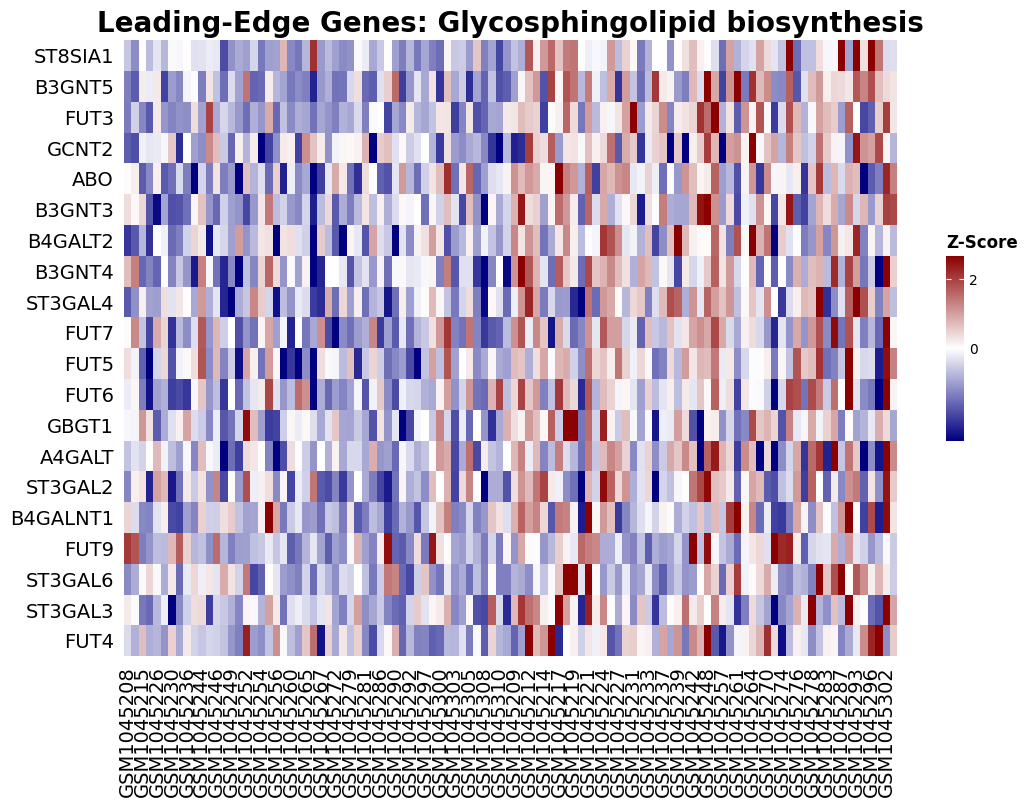

In [31]:
from gseapy import heatmap

if len(sig) > 0:
    # Use the top pathway by NES
    top_term = sig.iloc[0]["Term"]
    lead_col = "lead_genes" if "lead_genes" in sig.columns else "Lead_genes"
    lead_genes_str = sig.iloc[0][lead_col]

    if isinstance(lead_genes_str, str) and lead_genes_str:
        lead_genes = [g.strip() for g in lead_genes_str.split(";") if g.strip()]
        # Filter to genes present in heatmat
        available = [g for g in lead_genes if g in gs_res.heatmat.index]

        if available:
            import re
            title = re.sub(r" Homo sapiens.*", "", top_term)[:55]
            ax = heatmap(
                df      = gs_res.heatmat.loc[available],
                z_score = 0,
                title   = f"Leading-Edge Genes: {title}",
                figsize = (max(10, len(train_samples) * 0.12), max(4, len(available) * 0.4)),
            )
            plt.savefig("../../visuals/gsea_leading_edge_heatmap.png", dpi=150,
                        bbox_inches="tight")
            print(f"Saved: gsea_leading_edge_heatmap.png  ({len(available)} genes)")
            plt.show()
        else:
            print("No leading-edge genes found in heatmat index.")
    else:
        print("No leading-edge genes available for the top pathway.")